# 01. Подготовка данных: Boston Housing

**Цель ноутбука** — получить из сырого файла `data/housing.csv` чистый датасет для моделирования в `02_modeling.ipynb`.

План:
1. Загрузка с корректными типами (сразу без признака `B`).
2. Пропуски: явные и неявные (цензурирование `PRICE`).
3. Выбросы: сначала **проверяем форму распределений** (тесты на нормальность, Q-Q), потом выбираем метод поиска выбросов и решаем по каждому признаку отдельно, опираясь на доменную область.
4. Очистка данных.
5. Конструирование признаков.
6. Сохранение результата в `data/housing_prepared.csv`.

**Принцип этого ноутбука:** все преобразования здесь *stateless* — не используют статистик, посчитанных по всей выборке (средних, квантилей, границ обрезки). Всё, что «учится» на данных (масштабирование, подбор гиперпараметров), делается только на train в ноутбуке 02 — иначе будет утечка данных.

> **Этика данных.** Признак `B = 1000(Bk − 0.63)²` построен авторами исходного исследования (Harrison & Rubinfeld, 1978) из доли чернокожего населения района. Он кодирует расовый состав района как фактор цены, поэтому датасет был удалён из `scikit-learn` 1.2. Мы **не загружаем** этот столбец вовсе — ни для анализа, ни для моделирования.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import style as ss

ss.apply_default_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
RAW_PATH = DATA_DIR / "housing.csv"
TEST_PATH = DATA_DIR / "test.csv"
OUT_PATH = DATA_DIR / "housing_prepared.csv"
RANDOM_STATE = 13

## 1. Загрузка данных

Файл в классическом формате UCI: **нет заголовка**, столбцы разделены **переменным числом пробелов**. Поэтому:
- `sep=r"\s+"` — любое количество пробельных символов;
- `header=None` + `names=...` — задаём имена сами;
- `usecols` — признак `B` отбрасывается ещё на чтении;
- `dtype` — явные типы: `CHAS` — бинарный флаг (`int8`), `RAD` — целочисленный индекс с 9 уровнями (`int16`), остальное — `float64`.

In [2]:
ALL_COLUMNS = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS",
               "RAD", "TAX", "PTRATIO", "B", "LSTAT", "PRICE"]
USE_COLUMNS = [c for c in ALL_COLUMNS if c != "B"]   # этика: B не загружаем

DTYPES = {c: "float64" for c in USE_COLUMNS}
DTYPES.update({"CHAS": "int8", "RAD": "int16"})

df = pd.read_csv(
    RAW_PATH,
    sep=r"\s+",
    header=None,
    names=ALL_COLUMNS,
    usecols=USE_COLUMNS,
    dtype=DTYPES
)

print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.info()
df.head()

Размер: 506 строк × 13 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int8   
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int16  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(11), int16(1), int8(1)
memory usage: 45.1 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


In [3]:
test_data = df.sample(frac=0.10, random_state=RANDOM_STATE)
print('тестовые данные shape', test_data.shape)
df.drop(test_data.index, axis=0, inplace=True)
test_data.to_csv(TEST_PATH, index=False)

тестовые данные shape (51, 13)


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,3.406765,11.421978,10.948593,0.063736,0.549248,6.303985,68.015385,3.834736,9.312088,401.898901,18.433407,12.439890,22.763516
std,8.562920,23.405753,6.805929,0.244551,0.112788,0.692393,27.975501,2.073284,8.572017,167.115456,2.133172,6.897544,9.106508
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.920000,5.000000
25%,0.081065,0.000000,5.130000,0.000000,0.448000,5.893000,45.250000,2.164750,4.000000,277.000000,17.350000,6.970000,17.500000
50%,0.229270,0.000000,8.560000,0.000000,0.524000,6.211000,76.000000,3.317500,5.000000,329.000000,18.800000,11.120000,21.400000
75%,2.799060,12.500000,18.100000,0.000000,0.624000,6.617000,93.800000,5.214600,8.000000,666.000000,20.200000,16.325000,25.050000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,34.770000,50.000000


## 2. Пропуски

### 2.1 Явные пропуски, дубликаты и допустимые диапазоны

Помимо `NaN` проверим, что каждое значение физически осмысленно: доли — в `[0, 100]`, флаг — в `{0, 1}`, концентрации и расстояния — положительные. Значения-заглушки (`-1`, `999`, `0` там, где ноль невозможен) выдали бы себя именно здесь.

In [5]:
print("NaN по столбцам:", int(df.isna().sum().sum()))
print("Полных дубликатов строк:", int(df.duplicated().sum()))

# ожидаемые по смыслу диапазоны признаков
DOMAIN_RANGES = {
    "CRIM": (0, None), "ZN": (0, 100), "INDUS": (0, 100), "CHAS": (0, 1),
    "NOX": (0, 1), "RM": (1, None), "AGE": (0, 100), "DIS": (0, None),
    "RAD": (1, None), "TAX": (0, None), "PTRATIO": (1, None),
    "LSTAT": (0, 100), "PRICE": (0, None),
}
check = pd.DataFrame({
    "min": df.min(), "max": df.max(),
    "ожид. min": [DOMAIN_RANGES[c][0] for c in df.columns],
    "ожид. max": [DOMAIN_RANGES[c][1] for c in df.columns],
})
lo_ok = df.min() >= check["ожид. min"]
hi_ok = check["ожид. max"].isna() | (df.max() <= check["ожид. max"].fillna(np.inf))
check["в диапазоне"] = lo_ok & hi_ok
check

NaN по столбцам: 0
Полных дубликатов строк: 0


,min,max,ожид. min,ожид. max,в диапазоне
CRIM,0.00906,88.9762,0,NaN,True
ZN,0.00000,100.0000,0,100.0,True
INDUS,0.46000,27.7400,0,100.0,True
CHAS,0.00000,1.0000,0,1.0,True
NOX,0.38500,0.8710,0,1.0,True
RM,3.56100,8.7800,1,NaN,True
AGE,2.90000,100.0000,0,100.0,True
DIS,1.12960,12.1265,0,NaN,True
RAD,1.00000,24.0000,1,NaN,True
TAX,187.00000,711.0000,0,NaN,True


Явных пропусков, дубликатов и значений вне физического диапазона нет — **заполнять нечего**.

### 2.2 Неявный пропуск: цензурирование целевой переменной

Медианная цена `PRICE` (в тыс. $) при сборе данных была **ограничена сверху значением 50.0**: все районы дороже получили ровно 50. Это не выброс и не ошибка, а *правое цензурирование*: мы знаем только, что истинная цена **≥ 50**, но не знаем её значения.

Цензурированных наблюдений: 14 (3.1%)
Максимальная нецензурированная цена: 48.8


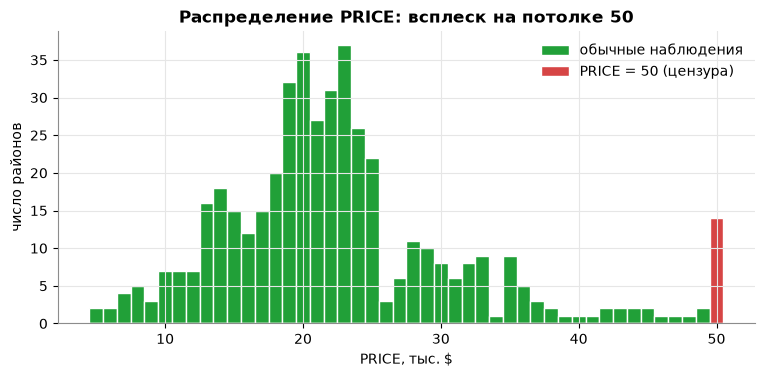

In [6]:
CENSOR_LEVEL = 50.0
is_censored = df["PRICE"] >= CENSOR_LEVEL

print(f"Цензурированных наблюдений: {is_censored.sum()} ({is_censored.mean():.1%})")
print(f"Максимальная нецензурированная цена: {df.loc[~is_censored, 'PRICE'].max()}")

fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.arange(4.5, 51.5, 1)
ax.hist(
    df.loc[~is_censored, "PRICE"], bins=bins, 
    color=ss.GREEN, edgecolor=ss.WHITE, label="обычные наблюдения"
)
ax.hist(
    df.loc[is_censored, "PRICE"], bins=bins, 
    color=ss.ERROR_RED, edgecolor=ss.WHITE, label="PRICE = 50 (цензура)"
)
ax.set_title("Распределение PRICE: всплеск на потолке 50")
ax.set_xlabel("PRICE, тыс. $")
ax.set_ylabel("число районов")
ax.legend()
plt.show()

На гистограмме видно: частота плавно убывает к 45–48, а на 50 — резкий всплеск. Для непрерывной величины такое скопление в одной точке похоже на след обрезки.

**Решение:**
- *Заполнить* (восстановить истинную цену) нельзя — информации нет, любое значение будет выдумкой.
- *Удалить* — тоже нет: это самые дорогие районы, они важны.
- Добавляем служебный флаг `PRICE_CENSORED`. В ноутбуке 02 эти строки **не участвуют в обучении**, а используются как отдельная тестовая выборка — проверка моделей на **экстраполяцию** (истинная цена этих районов выше всего, что модель видела на train).

Этот флаг — **не признак модели**: он вычислен из целевой переменной и в момент прогноза недоступен.

In [7]:
df["PRICE_CENSORED"] = is_censored.astype("int8")
df.loc[is_censored, ["CRIM", "RM", "LSTAT", "RAD", "TAX", "PRICE"]]

,CRIM,RM,LSTAT,RAD,TAX,PRICE
162,1.83377,7.802,1.92,5,403.0,50.0
163,1.51902,8.375,3.32,5,403.0,50.0
166,2.01019,7.929,3.70,5,403.0,50.0
186,0.05602,7.831,4.45,3,193.0,50.0
195,0.01381,7.875,2.97,4,255.0,50.0
204,0.02009,8.034,2.88,4,224.0,50.0
225,0.52693,8.725,4.63,8,307.0,50.0
257,0.61154,8.704,5.12,5,264.0,50.0
267,0.57834,8.297,7.44,5,264.0,50.0
283,0.01501,7.923,3.16,1,198.0,50.0


Большинство цензурированных районов выглядят как типичное дорогое жильё: много комнат (`RM` ≈ 7.5–8.7), очень низкий `LSTAT`. Но 5 районов с `RAD = 24` (центр Бостона) выбиваются: высокая преступность, `RM` 5–7 и при этом цена «≥ 50». Это **многомерная аномалия** — известная особенность датасета, и именно такие точки модели предскажут хуже всего. На обучение они не повлияют: все цензурированные строки уходят только в экстраполяционный тест.

## 3. Выбросы

### 3.1 Сначала — форма распределений

Популярные правила поиска выбросов опираются на предположение о распределении:
- правило **3σ (z-score)** предполагает нормальность;
- **правило IQR** (усы boxplot, `Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) откалибровано для симметричных распределений: для нормального закона за усы выходит лишь ≈ 0.7 % точек. Для скошенного распределения правило будет «ловить» обычный длинный хвост.

Поэтому сначала проверим нормальность: **тест Шапиро–Уилка** (H₀: выборка из нормального распределения), коэффициент асимметрии (skew) и избыточный эксцесс (kurtosis; у нормального оба ≈ 0).

In [8]:
CONTINUOUS = ["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE", "DIS", "TAX", "PTRATIO", "LSTAT"]


def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)


dist = pd.DataFrame({
    "skew": df[CONTINUOUS].apply(stats.skew),
    "kurtosis": df[CONTINUOUS].apply(stats.kurtosis),
    "Shapiro p-value": df[CONTINUOUS].apply(lambda s: stats.shapiro(s).pvalue),
    "выбросов по IQR": df[CONTINUOUS].apply(lambda s: iqr_outliers(s).sum()),
})
dist["нормальное (α=0.05)"] = dist["Shapiro p-value"] > 0.05
dist["Shapiro p-value"] = dist["Shapiro p-value"].map("{:.1e}".format)
dist = dist.round(3)
dist

,skew,kurtosis,Shapiro p-value,выбросов по IQR,нормальное (α=0.05)
CRIM,5.576,41.044,1.1e-35,72,False
ZN,2.203,3.891,2.6e-32,62,False
INDUS,0.353,-1.177,1.4e-16,0,False
NOX,0.770,0.017,1.8e-13,0,False
RM,0.538,2.040,4.6e-11,26,False
AGE,-0.576,-0.947,1.4e-16,0,False
DIS,0.985,0.482,1.0e-15,4,False
TAX,0.728,-1.038,1.4e-22,0,False
PTRATIO,-0.749,-0.332,2.1e-15,12,False
LSTAT,0.882,0.361,6.2e-13,8,False


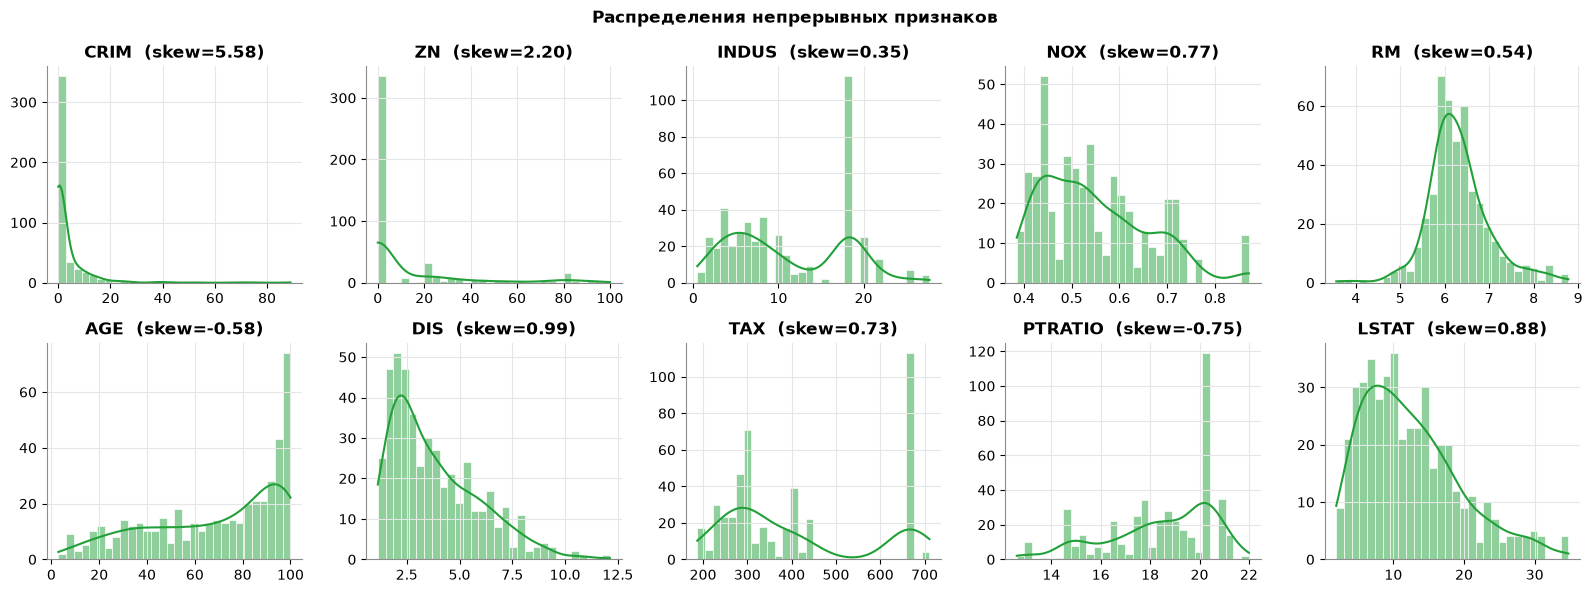

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), CONTINUOUS):
    sns.histplot(
        df[col], bins=30, kde=True, 
        ax=ax, color=ss.GREEN, edgecolor=ss.WHITE
    )
    ax.set_title(f"{col}  (skew={stats.skew(df[col]):.2f})")
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Распределения непрерывных признаков", fontweight="bold")
plt.tight_layout()
plt.show()

**Вывод по тестам:** ни один признак не распределён нормально (все p-value ≪ 0.05). Распределения разные по природе:

| Тип | Признаки | Что это значит для поиска выбросов |
|---|---|---|
| сильная правая асимметрия, тяжёлый хвост | `CRIM` (skew ≈ 5.5), `LSTAT`, `DIS` | «выбросы» по IQR могут быть просто хвостом |
| нулевая инфляция | `ZN` (73 % нулей) | Q1 = медиана = 0 ⇒ IQR-правило объявит выбросом почти любой ненулевой район |
| «ступенчатые» | `INDUS`, `TAX`, `AGE` | большие кластеры районов; выбросов по IQR нет |
| почти симметричный, но с тяжёлыми хвостами | `RM` (kurtosis ≈ 1.9) | IQR и 3σ применимы лишь приближённо; лучше робастный z-score |

Значит, **применять одно правило ко всем признакам и сразу обрезать (винзоризовать) — некорректно.** Разберём группы по очереди.

### 3.2 Скошенные признаки: выброс или хвост?

Если распределение близко к логнормальному, то в логарифмической шкале оно станет примерно симметричным, и «выбросы» исчезнут. Проверим Q-Q графиками (точки на прямой ⇒ нормальность) и повторным подсчётом IQR после логарифмирования.

Для `LSTAT` и `DIS` берём `log1p(x) = ln(1 + x)` и `ln(x)` соответственно. Для `CRIM` — обычный `ln(x)`: при x ≪ 1 `log1p(x) ≈ x`, то есть `log1p` почти ничего не меняет в левой части распределения. Нулей в `CRIM` нет (минимум 0.009), так что `ln` определён.

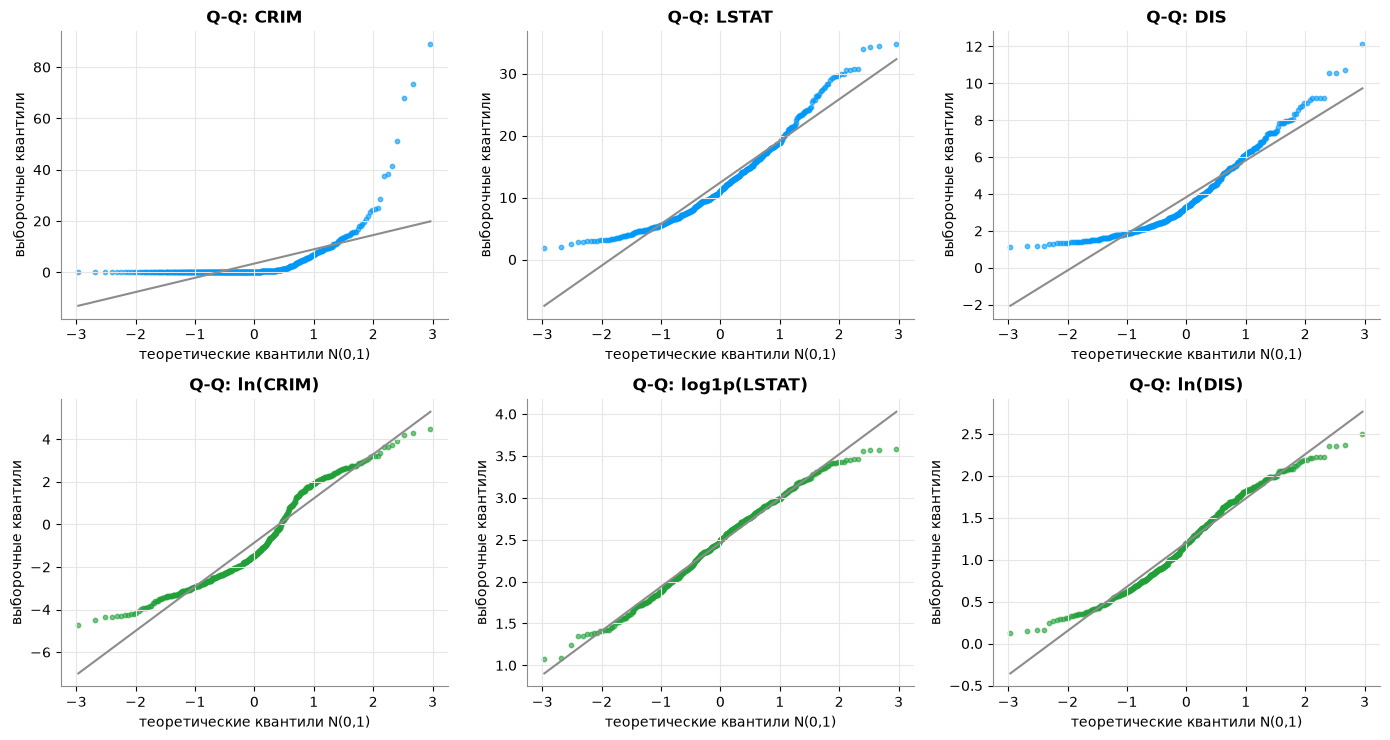

,преобразование,IQR-выбросов (исх.),IQR-выбросов (log),skew (исх.),skew (log)
CRIM,ln,72,0,5.58,0.47
LSTAT,log1p,8,0,0.88,-0.17
DIS,ln,4,0,0.99,0.11


In [10]:
LOG_TRANSFORMS = {
    "CRIM": ("ln", np.log), 
    "LSTAT": ("log1p", np.log1p), 
    "DIS": ("ln", np.log)
}
SKEWED = list(LOG_TRANSFORMS.keys())

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for j, col in enumerate(SKEWED):
    fname, func = LOG_TRANSFORMS[col]
    for i, (vals, label) in enumerate(
        [(df[col], col), (func(df[col]), f"{fname}({col})")]
    ):
        (osm, osr), (slope, intercept, _) = stats.probplot(vals, dist="norm")
        ax = axes[i, j]
        ax.scatter(osm, osr, s=10, color=ss.BLUE if i == 0 else ss.GREEN, alpha=0.6)
        ax.plot(osm, slope * osm + intercept, color=ss.GRAY, lw=1.5)
        ax.set_title(f"Q-Q: {label}")
        ax.set_xlabel("теоретические квантили N(0,1)")
        ax.set_ylabel("выборочные квантили")
plt.tight_layout()
plt.show()

compare = pd.DataFrame({
    "преобразование": [LOG_TRANSFORMS[c][0] for c in SKEWED],
    "IQR-выбросов (исх.)": [iqr_outliers(df[c]).sum() for c in SKEWED],
    "IQR-выбросов (log)": [iqr_outliers(LOG_TRANSFORMS[c][1](df[c])).sum() for c in SKEWED],
    "skew (исх.)": [stats.skew(df[c]) for c in SKEWED],
    "skew (log)": [stats.skew(LOG_TRANSFORMS[c][1](df[c])) for c in SKEWED],
}, index=SKEWED)
compare.round(2)

После логарифма асимметрия всех трёх признаков падает почти до нуля, Q-Q графики `LSTAT` и `DIS` становятся практически прямыми, и **IQR-выбросы исчезают полностью** (у `CRIM` было 66). Изгиб Q-Q у `ln(CRIM)` — скорее всего не отдельные аномальные точки, а группы районов: спокойные пригороды и центр города с высокой преступностью.

Посмотрим, *какие* районы дают экстремальный `CRIM`:

In [11]:
top_crime = df.nlargest(8, "CRIM")[["CRIM", "RAD", "TAX", "PTRATIO", "LSTAT", "PRICE"]]
print("Доля RAD = 24 среди 66 IQR-выбросов CRIM:",
      f"{(df.loc[iqr_outliers(df['CRIM']), 'RAD'] == 24).mean():.0%}")
top_crime

Доля RAD = 24 среди 66 IQR-выбросов CRIM: 100%


,CRIM,RAD,TAX,PTRATIO,LSTAT,PRICE
380,88.9762,24,666.0,20.2,17.21,10.4
418,73.5341,24,666.0,20.2,20.62,8.8
405,67.9208,24,666.0,20.2,22.98,5.0
410,51.1358,24,666.0,20.2,10.11,15.0
404,41.5292,24,666.0,20.2,27.38,8.5
398,38.3518,24,666.0,20.2,30.59,5.0
427,37.6619,24,666.0,20.2,14.52,10.9
413,28.6558,24,666.0,20.2,20.08,16.3


**Интерпретация `CRIM`.** Все экстремальные значения — районы центра Бостона (`RAD = 24`, `TAX = 666`, `PTRATIO = 20.2`), с высоким `LSTAT` и низкими ценами. Показатель рассчитан *на душу населения*: в промышленных районах с малым числом жителей даже умеренное число преступлений даёт очень большой `CRIM`. Это **реальные, а не ошибочные** данные.

### 3.3 `ZN`: нулевая инфляция, а не выбросы

Большой % районов вообще не имеют зонирования под крупные участки (`ZN = 0`). Из-за этого `Q1 = медиана = 0`, и правило IQR объявляет выбросами все районы с `ZN > около 30 - 35` — то есть **просто пригороды с зонированием под большие участки**. Это отдельная группа районов, и её разумнее описать бинарным признаком «есть такое зонирование», чем резать значения.

### 3.4 `RM` и `PTRATIO`: почти симметричные признаки

Для них используем **робастный z-score** (Iglewicz & Hoaglin): вместо среднего и σ, которые сами искажаются выбросами, берутся медиана и MAD:

$$M_i = 0.6745\,\frac{x_i - \operatorname{median}(x)}{\operatorname{MAD}}, \qquad |M_i| > 3.5 \Rightarrow \text{кандидат в выбросы}$$

In [12]:
def robust_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    return 0.6745 * (s - med) / mad


for col in ["RM", "PTRATIO"]:
    rz = robust_z(df[col])
    print(f"{col}: кандидатов |M| > 3.5 — {(rz.abs() > 3.5).sum()}  "
          f"(для сравнения, по IQR — {iqr_outliers(df[col]).sum()})")

rm_z = robust_z(df["RM"])
rm_out = df.loc[rm_z.abs() > 3.5, ["RM", "LSTAT", "RAD", "PRICE"]].sort_values("RM")
rm_out

RM: кандидатов |M| > 3.5 — 16  (для сравнения, по IQR — 26)
PTRATIO: кандидатов |M| > 3.5 — 0  (для сравнения, по IQR — 12)


,RM,LSTAT,RAD,PRICE
365,3.561,7.12,24,27.5
367,3.863,13.33,24,23.1
406,4.138,23.34,24,11.9
204,8.034,2.88,4,50.0
226,8.040,3.13,8,37.6
97,8.069,4.21,2,38.7
233,8.247,3.95,8,48.3
253,8.259,3.54,7,42.8
224,8.266,4.14,8,44.8
267,8.297,7.44,5,50.0


In [13]:
pt_z = robust_z(df["PTRATIO"])
pt_out = df.loc[pt_z.abs() > 3.5, ["PTRATIO", "LSTAT", "PRICE"]].sort_values("PTRATIO")
pt_out

,PTRATIO,LSTAT,PRICE


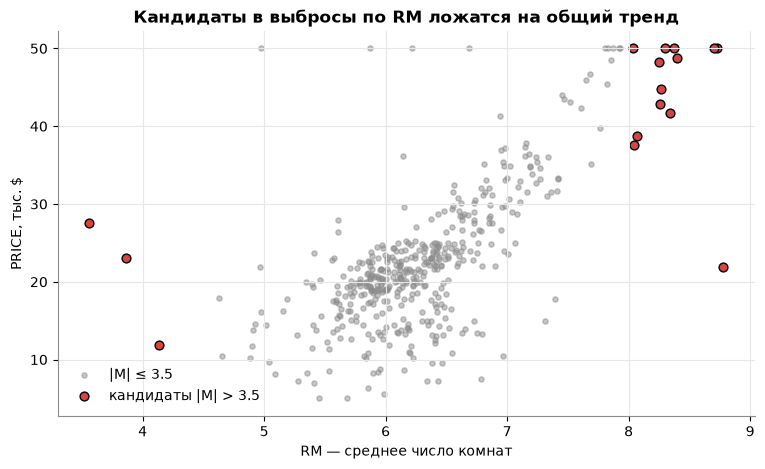

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
normal_mask = rm_z.abs() <= 3.5
ax.scatter(
    df.loc[normal_mask, "RM"], 
    df.loc[normal_mask, "PRICE"], s=14, alpha=0.5,
    color=ss.GRAY, label="|M| ≤ 3.5"
)
ax.scatter(
    df.loc[~normal_mask, "RM"], 
    df.loc[~normal_mask, "PRICE"], s=40,
    color=ss.ERROR_RED, edgecolor=ss.BLACK, 
    label="кандидаты |M| > 3.5"
)
ax.set_xlabel("RM — среднее число комнат")
ax.set_ylabel("PRICE, тыс. $")
ax.set_title("Кандидаты в выбросы по RM ложатся на общий тренд")
ax.legend()
plt.show()

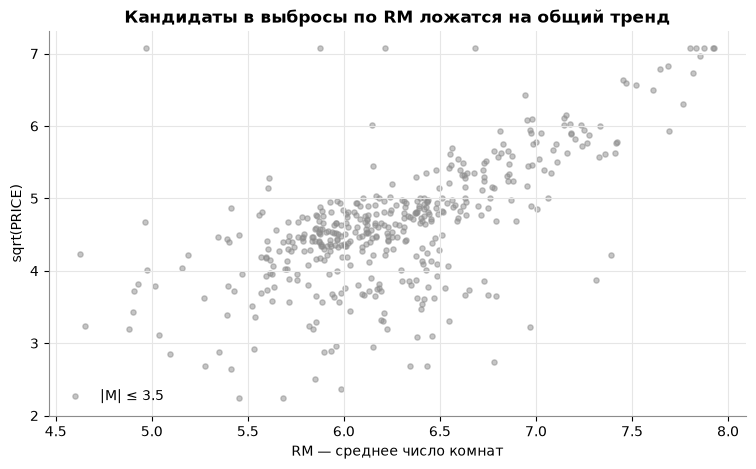

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
normal_mask = (rm_z.abs() <= 3.5)
ax.scatter(
    df.loc[normal_mask, "RM"], 
    np.sqrt(df.loc[normal_mask, "PRICE"]), s=14, alpha=0.5,
    color=ss.GRAY, label="|M| ≤ 3.5"
)
ax.set_xlabel("RM — среднее число комнат")
ax.set_ylabel("sqrt(PRICE)")
ax.set_title("Кандидаты в выбросы по RM ложатся на общий тренд")
ax.legend()
plt.show()

**Интерпретация `RM`.** Кандидаты делятся на две понятные группы:
- `RM` < 4.5 — районы центра (`RAD = 24`) с маленькими квартирами;
- `RM` > 8 — богатые пригороды: низкий `LSTAT`, высокая цена.

Точки продолжают общий тренд «больше комнат → дороже», значения физически возможны ⇒ **реальные крайние районы**, не ошибки.

Одна точка выбивается из тренда — район 364: `RM` = 8.78 в центре города при цене 21.9. Значение физически возможно (отдельный квартал крупных старых домов), поэтому не удаляем.

### 3.5 Итог по выбросам

| Признак | Почему «выброс» по IQR | Вердикт | Действие |
|---|---|---|---|
| `CRIM` | правый хвост логнормального распределения; районы центра | реальные значения | `ln` (новый признак) |
| `LSTAT`, `DIS` | правый хвост; в log-шкале выбросов 0 | реальные значения | `log1p` и `ln` соответственно (новый признак) |
| `ZN` | нулевая инфляция, Q1 = 0 | отдельная группа районов | бинарный флаг `HAS_ZN` |
| `RM` | тяжёлые хвосты симметричного распределения | крайние, но согласованные районы | оставляем |
| `PRICE = 50` | цензура, а не выброс | неизвестная истинная цена | флаг, отдельный тест в 02 |


Отдельно отметим структурную особенность: 108 елементов центра Бостона имеют **одинаковые** `RAD = 24`, `TAX = 666`, `PTRATIO = 20.2` Это не ошибка, но это кластер, который стоит пометить явно.

In [16]:
city = (df["RAD"] == 24)
print("Районов с RAD = 24:", city.sum())
print("Из них с TAX = 666 и PTRATIO = 20.2:",
      (city & (df["TAX"] == 666) & (df["PTRATIO"] == 20.2)).sum())

Районов с RAD = 24: 113
Из них с TAX = 666 и PTRATIO = 20.2: 113


## 5. Конструирование признаков

Все новые признаки — **детерминированные функции одной строки** (без статистик по выборке и без `PRICE`), поэтому их можно считать до разбиения без утечки.

| Признак | Формула | Доменный смысл |
|---|---|---|
| `LOG_CRIM` | `ln(CRIM)` | преступность различается на порядки — важен порядок величины, а не абсолютная разница |
| `LOG_LSTAT` | `log1p(LSTAT)` | цена убывает по `LSTAT` с замедлением (рост с 2 % до 7 % важнее, чем с 30 % до 35 %) |
| `LOG_DIS` | `ln(DIS)` | «лишний» километр до центра значим рядом с городом и почти не значим на окраине |
| `RM_SQ` | `RM²` | - |
| `HAS_ZN` | `ZN > 0` | в районе есть зонирование под крупные участки — признак пригорода |
| `CITY_CORE` | `RAD == 24` | кластер районов центра Бостона с общими городскими `TAX`/`PTRATIO` |

In [17]:
df["LOG_CRIM"] = np.log(df["CRIM"])
df["LOG_LSTAT"] = np.log1p(df["LSTAT"])
df["LOG_DIS"] = np.log(df["DIS"])
df["RM_SQ"] = df["RM"] ** 2
df["HAS_ZN"] = (df["ZN"] > 0).astype("int8")
df["CITY_CORE"] = (df["RAD"] == 24).astype("int8")

NEW_FEATURES = ["LOG_CRIM", "LOG_LSTAT", "LOG_DIS", "RM_SQ", "HAS_ZN", "CITY_CORE"]
df[NEW_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
LOG_CRIM,455.0,-0.855,2.128,-4.704,-2.513,-1.473,1.029,4.488
LOG_LSTAT,455.0,2.465,0.527,1.072,2.076,2.495,2.852,3.577
LOG_DIS,455.0,1.205,0.530,0.122,0.772,1.199,1.651,2.495
RM_SQ,455.0,40.219,9.035,12.681,34.727,38.577,43.785,77.088
HAS_ZN,455.0,0.264,0.441,0.000,0.000,0.000,1.000,1.000
CITY_CORE,455.0,0.248,0.433,0.000,0.000,0.000,0.000,1.000


### Помогают ли новые признаки понять данные?

Коэффициент Пирсона измеряет **линейную** связь, Спирмена — **монотонную**. Если после преобразования Пирсон с ценой заметно вырос и приблизился к Спирмену, значит преобразование «выпрямило» зависимость — именно это нужно линейной модели. Для бинарных флагов сравниваем средние цены групп.

In [18]:
obs = df[df["PRICE_CENSORED"] == 0]
pairs = [("CRIM", "LOG_CRIM"), ("LSTAT", "LOG_LSTAT"), ("DIS", "LOG_DIS"), ("RM", "RM_SQ")]

rows = []
for raw, new in pairs:
    rows.append({
        "признак": f"{raw} → {new}",
        "Pearson исх.": obs[raw].corr(obs["PRICE"]),
        "Pearson нов.": obs[new].corr(obs["PRICE"]),
        "Spearman": obs[raw].corr(obs["PRICE"], method="spearman"),
    })
pd.DataFrame(rows).set_index("признак").round(3)

,Pearson исх.,Pearson нов.,Spearman
признак,,,
CRIM → LOG_CRIM,-0.430,-0.551,-0.576
LSTAT → LOG_LSTAT,-0.757,-0.815,-0.842
DIS → LOG_DIS,0.352,0.424,0.487
RM → RM_SQ,0.686,0.707,0.631


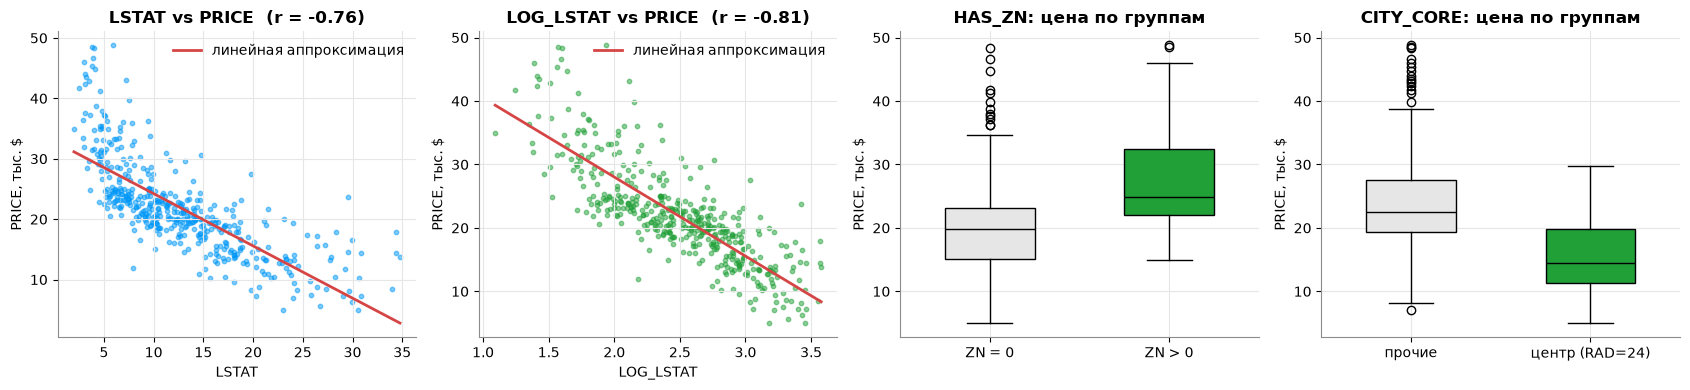

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, col in zip(axes[:2], ["LSTAT", "LOG_LSTAT"]):
    ax.scatter(obs[col], obs["PRICE"], s=10, alpha=0.5, color=ss.BLUE if col == "LSTAT" else ss.GREEN)
    k, b = np.polyfit(obs[col], obs["PRICE"], 1)
    xs = np.linspace(obs[col].min(), obs[col].max(), 50)
    ax.plot(xs, k * xs + b, color=ss.ERROR_RED, lw=2, label="линейная аппроксимация")
    ax.set_title(f"{col} vs PRICE  (r = {obs[col].corr(obs['PRICE']):.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("PRICE, тыс. $")
    ax.legend(loc="upper right")

for ax, flag, names in [(axes[2], "HAS_ZN", ["ZN = 0", "ZN > 0"]),
                        (axes[3], "CITY_CORE", ["прочие", "центр (RAD=24)"])]:
    groups = [obs.loc[obs[flag] == v, "PRICE"] for v in (0, 1)]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5, medianprops={"color": ss.BLACK})
    ax.set_xticks([1, 2], names)
    for patch, color in zip(bp["boxes"], [ss.GRAY_LIGHT, ss.GREEN]):
        patch.set_facecolor(color)
    ax.set_title(f"{flag}: цена по группам")
    ax.set_ylabel("PRICE, тыс. $")

plt.tight_layout()
plt.show()

- `LOG_LSTAT`: линейная связь с ценой заметно сильнее, чем у исходного `LSTAT` (прямая хорошо ложится на облако, а у исходного признака видна «дуга»).
- `LOG_CRIM`, `LOG_DIS`: Пирсон растёт и приближается к Спирмену ⇒ связь стала ближе к линейной.
- `HAS_ZN` и `CITY_CORE` чётко разделяют районы по уровню цен: медиана в центре ≈ 14 против ≈ 22.5 у остальных, районы с крупными участками дороже (≈ 25 против ≈ 19.5).

Посмотрим на взаимосвязи признаков, которые пойдут в модель (коэффициент Спирмена — устойчив к скошенности).

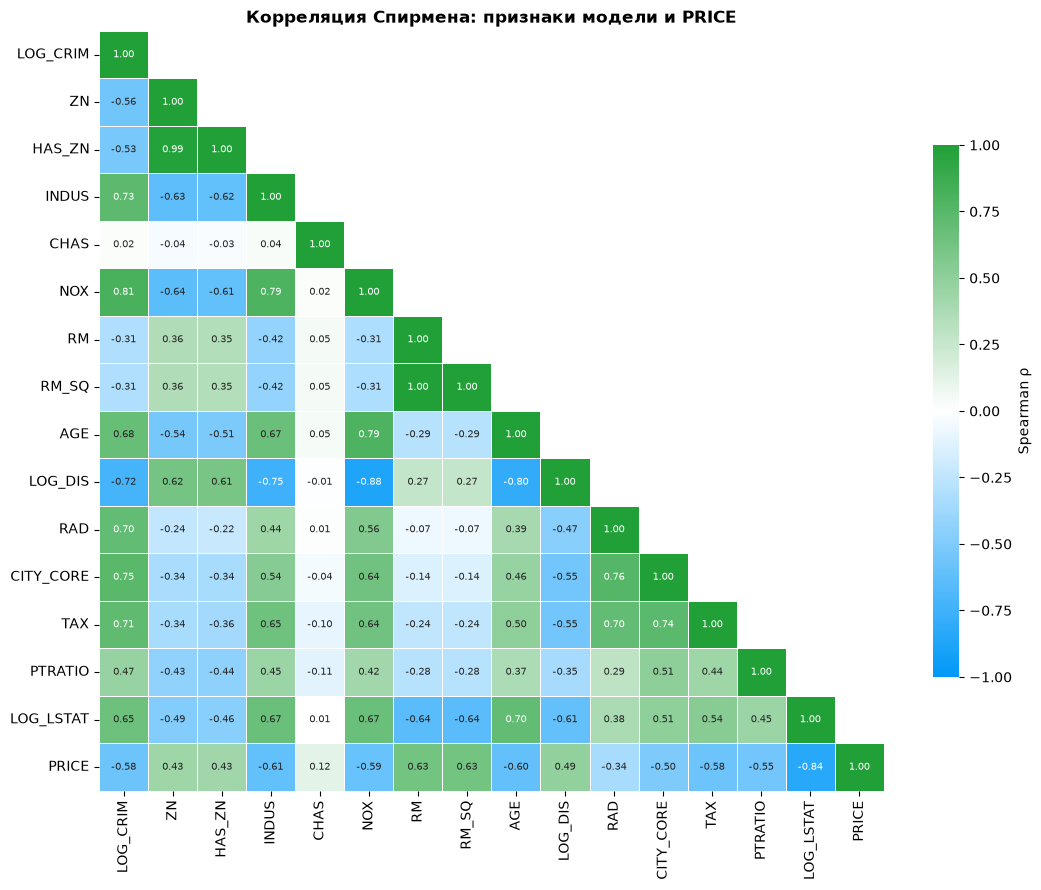

In [20]:
MODEL_FEATURES = ["LOG_CRIM", "ZN", "HAS_ZN", "INDUS", "CHAS", "NOX", "RM", "RM_SQ",
                  "AGE", "LOG_DIS", "RAD", "CITY_CORE", "TAX", "PTRATIO", "LOG_LSTAT"]

corr = obs[MODEL_FEATURES + ["PRICE"]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, cmap=ss.DIVERGING_CMAP, vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax
)
ax.set_title("Корреляция Спирмена: признаки модели и PRICE")
ax.grid(False)
plt.tight_layout()
plt.show()

Главные предикторы цены — `LOG_LSTAT` (ρ ≈ −0.84) и `RM` (≈ 0.6). Заметна мультиколлинеарность: `RM`/`RM_SQ` (ρ = 1 по построению), `ZN`/`HAS_ZN`, `RAD`/`TAX`/`CITY_CORE`, `NOX`/`INDUS`/`LOG_DIS`. Для прогноза это не критично, но **коэффициенты линейной регрессии будут нестабильными** — поэтому в 02 используем и регуляризованную модель (Ridge).

## 6. Сохранение

In [21]:
df.to_csv(OUT_PATH, index=False)